In [1]:
import pandas, numpy, scipy

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/055_bruara/results/transcriptomics/profiles/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(27771, 9)


,DMSO_Trans_1,DMSO_Trans_2,DMSO_Trans_3,R_AM_Trans_1,R_AM_Trans_2,R_AM_Trans_3,S_AM_Trans_1,S_AM_Trans_2,S_AM_Trans_3
ENSDARG00000000001.6,4.570837,1.983404,3.295762,1.845297,2.387153,2.370740,3.857496,2.180049,4.520917
ENSDARG00000000002.8,1.621505,0.809430,1.736672,1.138338,1.935137,1.934972,1.755778,1.132271,2.394230
ENSDARG00000000018.9,22.135390,16.368824,23.085430,18.654597,22.396839,23.138014,25.188458,22.030205,24.698572
ENSDARG00000000019.9,34.394810,15.374659,30.516654,21.125880,18.279317,26.924723,28.035350,18.302399,30.339853
ENSDARG00000000068.9,6.134319,5.668954,6.108218,5.301847,5.903606,5.907752,5.956085,6.232253,5.867924
...,...,...,...,...,...,...,...,...,...
ENSDARG00000117823.1,1.092805,1.223579,0.000000,0.000000,0.000000,1.435310,0.000000,0.000000,0.000000
ENSDARG00000117824.1,8.082351,7.344734,5.755109,5.958671,6.713451,8.893107,7.222103,4.948334,8.082515
ENSDARG00000117825.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSDARG00000117826.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
for element in expression.columns:
    print(element)

DMSO_Trans_1
DMSO_Trans_2
DMSO_Trans_3
R_AM_Trans_1
R_AM_Trans_2
R_AM_Trans_3
S_AM_Trans_1
S_AM_Trans_2
S_AM_Trans_3


# 3. filter and transform

In [7]:
substantial_expression = expression[expression.max(axis=1) >= 10] # 2 100
high_expression = expression[expression.max(axis=1) >= 250]

print(substantial_expression.shape)
print(high_expression.shape)

(7840, 9)
(522, 9)


In [8]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [9]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.37324046 0.17761818]


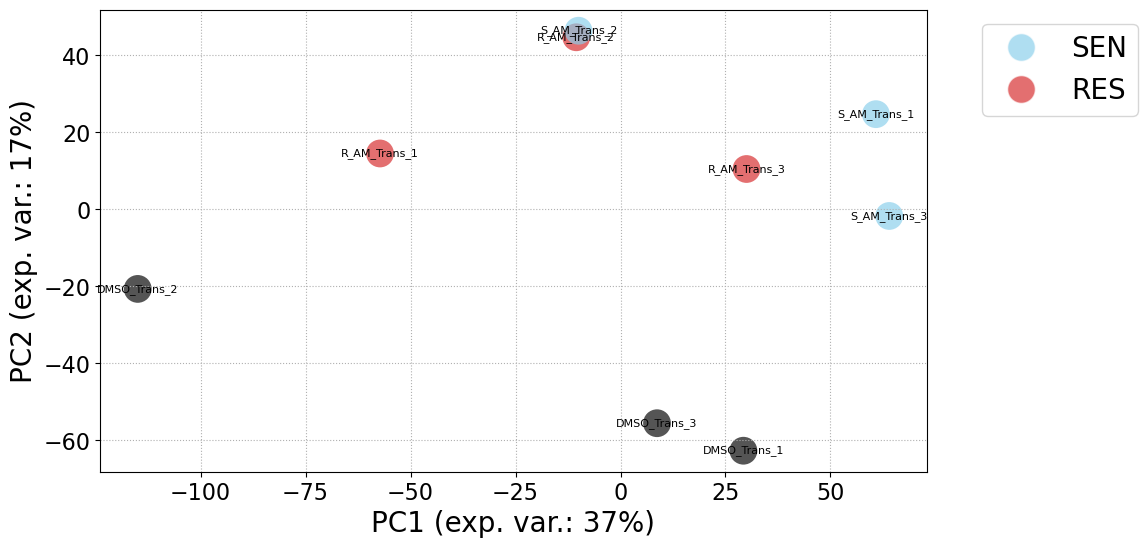

In [10]:
for i in range(len(new)):

    # colors
    name = expression.columns[i]
    
    if 'S_' in name:
        the_color = 'skyblue'
    elif 'R_' in name:
        the_color = 'tab:red'
    elif 'DMSO' in name:
        the_color = 'black'
    else:
        print('error')
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')

legend_elements = [
    
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    
]

matplotlib.pyplot.legend(legend_elements, ['SEN', 'RES'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('pca.svg')

# 4. visualize high expression

In [11]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.35637216 0.22703637]


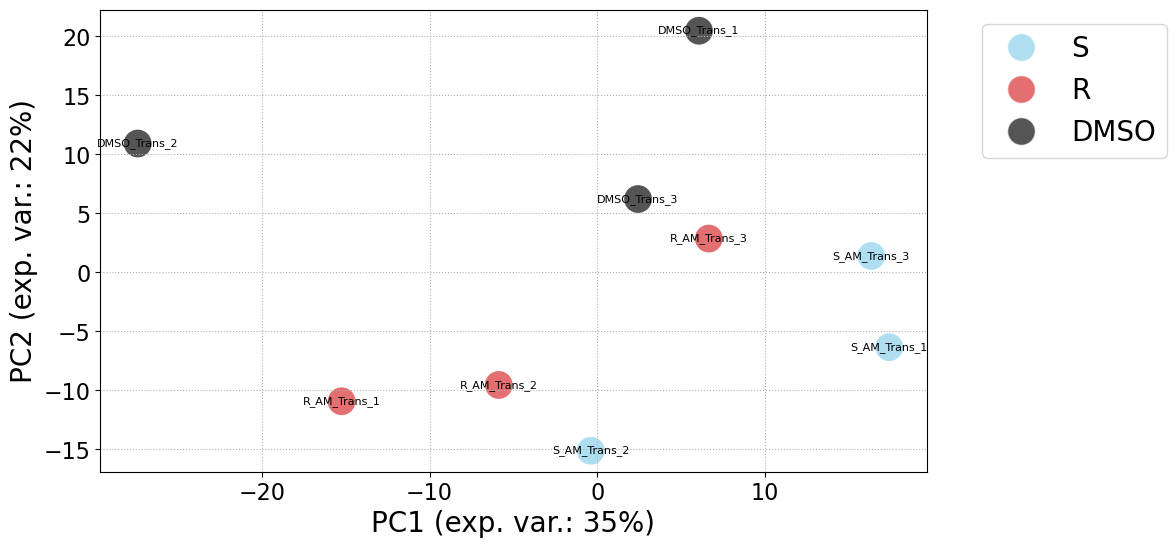

In [12]:
for i in range(len(new)):

        
    # colors
    name = expression.columns[i]
    
    if 'S_' in name:
        the_color = 'skyblue'
    elif 'R_' in name:
        the_color = 'tab:red'
    elif 'DMSO' in name:
        the_color = 'black'
    else:
        print('error')
    
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=the_color, marker='o', alpha=2/3, edgecolors='none')
    epsilon = 0
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')

legend_elements = [
    
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='skyblue', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='tab:red', markeredgecolor='white', markersize=20, alpha=2/3),
    matplotlib.lines.Line2D([0], [0], color='white', marker='o', markerfacecolor='black', markeredgecolor='white', markersize=20, alpha=2/3)
    
]

matplotlib.pyplot.legend(legend_elements, ['S', 'R', 'DMSO'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

#matplotlib.pyplot.show()
matplotlib.pyplot.savefig('pca.svg')

In [13]:
# 5. distributions

In [14]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

,DMSO_Trans_1,DMSO_Trans_2,DMSO_Trans_3,R_AM_Trans_1,R_AM_Trans_2,R_AM_Trans_3,S_AM_Trans_1,S_AM_Trans_2,S_AM_Trans_3
ENSDARG00000000001.6,2.477894,1.576959,2.102914,1.508579,1.760073,1.753065,2.280213,1.669049,2.464908
ENSDARG00000000002.8,1.390395,0.855535,1.452423,1.096490,1.553428,1.553347,1.462459,1.092391,1.763084
ENSDARG00000000018.9,4.532030,4.118428,4.590089,4.296795,4.548242,4.593235,4.710859,4.525455,4.683616
ENSDARG00000000019.9,5.145466,4.033393,4.978042,4.467663,4.268982,4.803471,4.859739,4.270708,4.969927
ENSDARG00000000068.9,2.834776,2.737460,2.829488,2.655775,2.787350,2.788216,2.798275,2.854445,2.779874


162
16.56678063221645


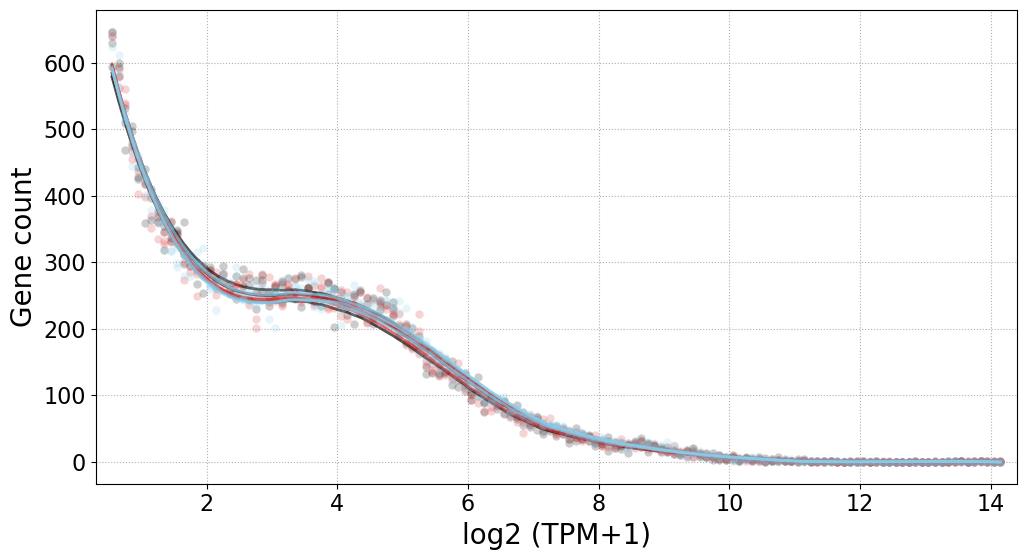

In [15]:
found_max = 16.2
number_of_bins = int(found_max*10)
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    # colors
    name = expression.columns[i]
    
    if 'S_' in name:
        the_color = 'skyblue'
    elif 'R_' in name:
        the_color = 'tab:red'
    elif 'DMSO' in name:
        the_color = 'black'
    else:
        print('error')
    
    log2TPM = log2_tpm_PO.loc[:, name]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    #print(plotting_x)
    
    matplotlib.pyplot.plot(plotting_x, plotting_hist, 'o', alpha=1/5, mec='none', color=the_color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=2/3, color=the_color)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])
#matplotlib.pyplot.ylim([0, 400])

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)